# Star-shaped flat-top beam shaping in the far field

This notebook designs a **phase-only flat-optics element** that transforms a Gaussian input beam into a star-shaped flat-top radiant-intensity distribution in the far field. The phase is found with a physics-informed neural network (PINN) that solves the far-field Monge--Ampère beam-shaping equation.

The workflow is:

1. define the Gaussian source and star-shaped target in angular coordinates $(\alpha,\beta)$,
2. train or load the PINN phase profile,
3. inspect the learned phase mask, and
4. validate the result independently with scalar far-field diffraction.


## Imports and numerical backend

The code uses **PyTorch** for the PINN and automatic differentiation, NumPy and Matplotlib for array manipulation and plotting, and the local `pinn_shaper` package for the Monge--Ampère solver. If a CUDA GPU is available, PyTorch tensors are placed on the GPU by default.


In [1]:
import torch

if torch.cuda.is_available():
    torch.set_default_device("cuda")

import matplotlib.pyplot as plt
import numpy as np

from pinn_shaper import Farfield_PINN
from pinn_shaper import um, mm
from pinn_shaper import load_image, create_interpolator
from scipy.ndimage import gaussian_filter as scipy_gaussian_filter


## Problem setup: Gaussian source and star-shaped target

The incident irradiance is a circular Gaussian,

$$
I(x,y)=\exp\!\left[-2\left(\frac{\sqrt{x^2+y^2}}{w_I}\right)^2\right],
$$

sampled over a square source aperture. The desired far-field radiant intensity is specified in direction-cosine coordinates $(\alpha,\beta)$ by loading and smoothing a star-shaped image. The image is converted into a differentiable interpolator over $[-1,1]\times[-1,1]$, allowing the PINN to evaluate

$$
I_{e,\Omega\cos\theta}(\alpha,\beta)
$$

at arbitrary mapped coordinates during training.

For the far-field formulation, the normalized phase maps source points directly into angular coordinates through

$$
(\alpha,\beta)=\left(\bar\Phi_{\bar x},\bar\Phi_{\bar y}\right),
$$

and the governing residual is based on

$$
I_{e,\Omega\cos\theta}\!\left(\bar\Phi_{\bar x},\bar\Phi_{\bar y}\right)
\left|\bar\Phi_{\bar x\bar x}\bar\Phi_{\bar y\bar y}
-\bar\Phi_{\bar x\bar y}^{2}\right|
=M^2 I(M\bar x,M\bar y).
$$

The original star-shaped setup is retained: a 1 mm square source aperture, a wavelength of 1 µm, a smoothed `star.png` target, and a fully connected PINN with 3 hidden layers and 150 neurons per layer.


In [2]:
extent_source = 1000 * um
w_I = 50.6 * um / (100 * um) * extent_source / 2
wavelength = 1.0 * um


def I_fun(x, y):
    # Gaussian source irradiance with beam waist w_I.
    r = torch.sqrt(x**2 + y**2)
    return torch.exp(-(r / w_I) ** 2) ** 2


# Smoothed star-shaped far-field target.
target_image = np.asarray(scipy_gaussian_filter(load_image("images/star.png"),10,mode="nearest",cval=0,),dtype=np.float32)
Irad_fun = create_interpolator(torch.tensor(target_image),mode="bilinear",region=[-1, 1, -1, 1],align_corners=True)


def constrain_fn(points):
    # Radial constraint used by the original star-shaped notebook.
    return points[:, 0:1] ** 2 + points[:, 1:2] ** 2


# Initialize the PINN solver (the network is built now)
solver = Farfield_PINN(I_fun, Irad_fun, extent_source, wavelength,
                        integration_points=5000,
                        hidden_layers=3, num_features=150,
                        constrain=True,  symmetry=None, 
                        constrain_fn = constrain_fn)

## Inspect the normalized source and target

These plots provide a quick check before training. The first shows the Gaussian irradiance across the source aperture, and the second shows the prescribed star-shaped radiant-intensity distribution in the $(\alpha,\beta)$ far-field domain.


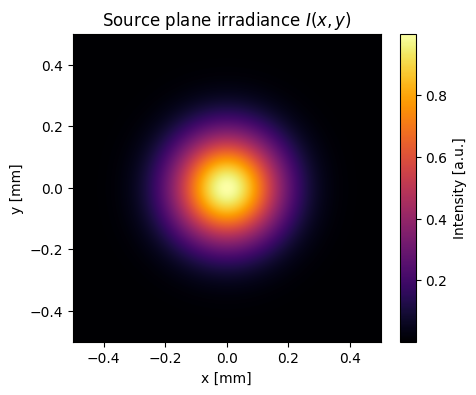

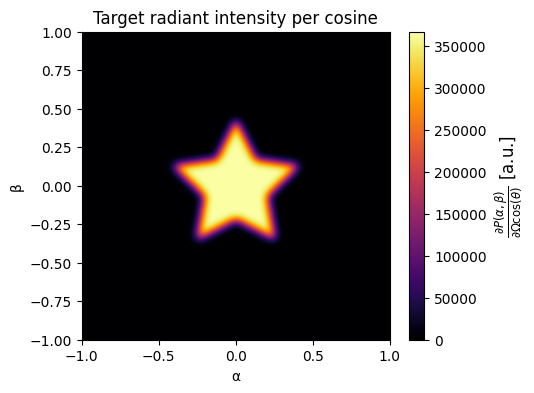

In [3]:
solver.plot_source_irradiance()
solver.plot_target_radiant_intensity()


## PINN training schedule

The phase network is optimized in stages. Adam first reduces the residual from a random initialization, and L-BFGS then refines the solution with larger sets of collocation points. The `loss_weights` array controls the relative contributions of the Monge--Ampère residual and the additional constraint terms.

The training schedule and numerical parameters below are kept from the original star-shaped notebook.


In [ ]:
residual_power = 1.5
loss_weights = [100.0, 1, 1]
noise_amplitude = 0.0
add_noise = False
effective_noise = noise_amplitude if add_noise else 0.0

num_test_interior = 1000
num_test_boundary = 200

print("Run Phase 1: Adam")
solver.run_phase(
    optimizer_type="adam",
    iterations=1000,
    num_domain=1000,
    num_boundary=100,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.001,
)

print("Run Phase 2: Adam")
solver.run_phase(
    optimizer_type="adam",
    iterations=2000,
    num_domain=1500 * 10,
    num_boundary=100 * 10,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.0001,
)

print("Run Phase 3: L-BFGS")
solver.run_phase(
    optimizer_type="lbfgs",
    num_domain=1500 * 15,
    num_boundary=100 * 15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.001,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=1000,
    lr_lbfgs=1,
)

print("Run Phase 4: L-BFGS")
solver.run_phase(
    optimizer_type="lbfgs",
    num_domain=1500 * 15,
    num_boundary=100 * 15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.0,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=800,
    lr_lbfgs=1,
)

solver.print_final_test_loss(
    num_test_interior,
    num_test_boundary,
    residual_power,
    loss_weights,
    effective_noise,
)


## Load the trained model

Training can take time, so this cell loads the existing star-shaped checkpoint. Uncomment the save line after training to overwrite or create the checkpoint with newly trained weights.


In [4]:
#torch.save(solver.net.state_dict(), 'star_flat-top-farfield_model.pth') # save the trained model
solver.net.load_state_dict(torch.load('saved_models/star_flat-top-farfield_model.pth')) # load the trained model

<All keys matched successfully>

## Visualize the learned phase mask

The learned phase $\Phi(x,y)$ is evaluated on a dense grid. The left panel shows unwrapped phase contours, which reveal the smooth phase potential produced by the PINN. The right panel shows the same phase with a cyclic colour map and retains the central-aperture zoom used in the original star-shaped notebook.


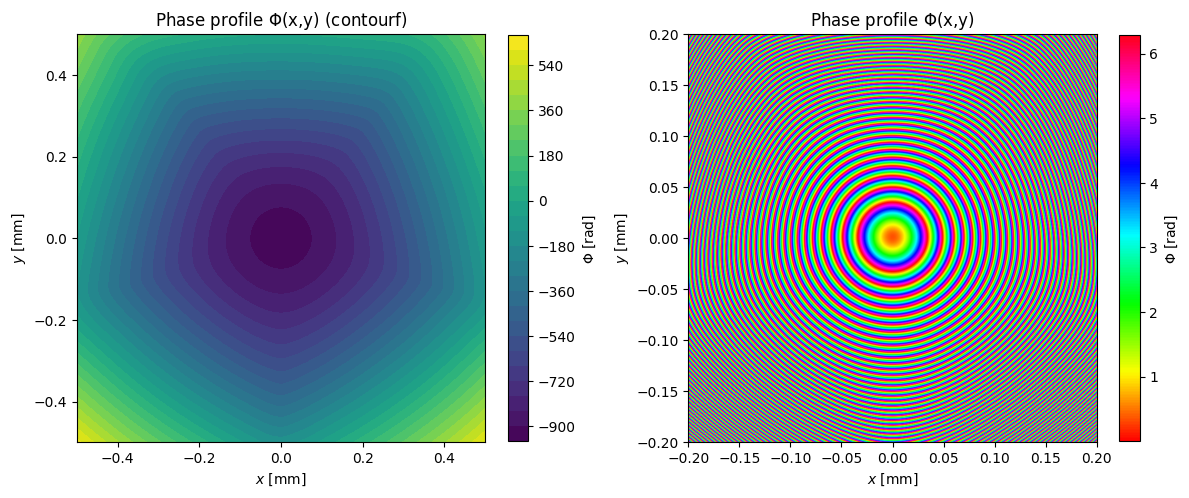

In [5]:
phi_spline = solver.get_phi_spline()


nx, ny = 2000, 2000
x = np.linspace(-solver.M, solver.M, nx)
y = np.linspace(-solver.M, solver.M, ny)
X, Y = np.meshgrid(x, y, indexing='xy')




fig, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1 = axs[0]
im = ax1.contourf(phi_spline(x,y), origin = 'lower',  levels = 30, extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel('$x$ [mm]')
ax1.set_title(r"Phase profile $\Phi$(x,y) (contourf)")
ax1.set_aspect(1) 

ax2 = axs[1]
im = ax2.imshow((phi_spline(x,y) )  %(np.pi*2), origin = 'lower', cmap = 'hsv', extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax2.set_ylabel("$y$ [mm]")
ax2.set_xlabel('$x$ [mm]')
ax2.set_title(r"Phase profile $\Phi$(x,y)")
ax2.set_aspect(1) 
ax2.set_xlim([-0.2, 0.2])
ax2.set_ylim([-0.2, 0.2])
fig.tight_layout()
plt.show()


## Scalar far-field diffraction validation

The PINN is trained from a ray and energy-conservation equation, but the resulting phase should also be checked independently with wave optics. The complex field immediately after the phase mask is

$$
U(x,y)=\sqrt{I(x,y)}\,e^{i\Phi(x,y)}.
$$

Its scalar far field is computed with `MonochromaticField.get_farfield()` from `diffractsim`. The returned quantity is the radiant intensity per projected solid angle,

$$
\frac{\partial P(\alpha,\beta)}{\partial\Omega\cos\theta},
$$

which is the same physical quantity used in the far-field Monge--Ampère equation.


In [6]:
from diffractsim import MonochromaticField

Nx = 2048
Ny = 2048

farfield_simulator = MonochromaticField(
    wavelength=wavelength,
    extent_x=extent_source,
    extent_y=extent_source,
    Nx=Nx,
    Ny=Ny,
)


def I_fun_numpy(x, y):
    # NumPy version of the Gaussian source irradiance.
    r = np.sqrt(x**2 + y**2)
    return np.exp(-(r / w_I) ** 2) ** 2


farfield_simulator.E = np.sqrt(I_fun_numpy(farfield_simulator.xx, farfield_simulator.yy))* np.exp( 1j* phi_spline(farfield_simulator.x, farfield_simulator.y))


alpha, beta, radiant_intensity_percos = farfield_simulator.get_farfield()


## Plot the PINN far-field result

The left panel shows the simulated star-shaped radiant intensity over the angular square. The right panel compares the central cross section at $\beta=0$ with the prescribed target profile. The horizontal axis is converted from direction cosine $\alpha$ to the propagation angle $\theta=\arcsin(\alpha)$.


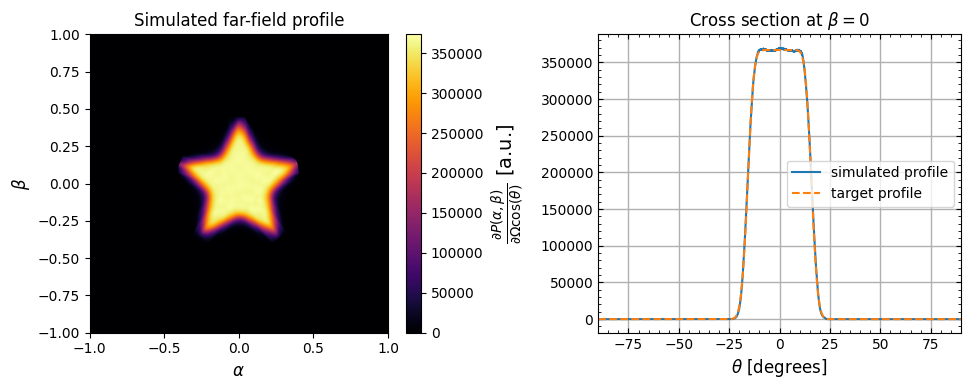

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ax1 = axs[0]
im = ax1.imshow(radiant_intensity_percos,origin="lower",cmap="inferno",extent=[alpha[0],alpha[-1],beta[0],beta[-1],],aspect="auto")
cb = fig.colorbar(im,ax=ax1,orientation="vertical",fraction=0.045,)
cb.set_label(r"$\frac{\partial P(\alpha,\beta)}"r"{\partial\Omega\cos(\theta)}$ [a.u.]",size=14)

ax1.set_ylabel(r"$\beta$", size=12)
ax1.set_xlabel(r"$\alpha$", size=12)
ax1.set_title("Simulated far-field profile")
ax1.set_aspect("equal")
ax1.set_xlim([-1.0, 1.0])
ax1.set_ylim([-1.0, 1.0])

ax2 = axs[1]
ax2.tick_params(axis="both",which="both",direction="in",right=True,top=True)
ax2.minorticks_on()
ax2.grid(which="major", linestyle="-", linewidth=1.0)

theta_degrees = (np.arcsin(np.clip(alpha, -1, 1))* 180/ np.pi)
ax2.plot(theta_degrees,radiant_intensity_percos[Ny // 2, :],label="simulated profile")

network_device = next(solver.net.parameters()).device
alpha_torch = torch.from_numpy(np.asarray(alpha, dtype=np.float32)).to(network_device)

target_cross_section = solver.Irad_fun_norm(alpha_torch,torch.zeros_like(alpha_torch),).detach().cpu().numpy().ravel()

ax2.plot(theta_degrees,target_cross_section,"--",label="target profile",)
ax2.set_xlim([-90, 90])
ax2.set_title(r"Cross section at $\beta=0$")
ax2.set_xlabel(r"$\theta$ [degrees]", size=12)
ax2.legend()
fig.tight_layout()
plt.show()
